<a href="https://colab.research.google.com/github/ahmadtariq2004/Evolvix-Ai-ML-Internship-ahmadtariq2004/blob/main/Week_2/Task_1/Week_2_Task_1_Ahmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classification Model Comparison

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load and Prepare Data

I'm loading the Breast Cancer dataset, which is a common binary classification dataset. Then, I'll split it into training and testing sets to properly evaluate the models.

In [ ]:
# Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Target classes: {data.target_names}")

Training set size: 398 samples
Testing set size: 171 samples
Number of features: 30
Target classes: ['malignant' 'benign']


### 2. Train Different Models

Now, I will train three different classification models: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.

In [ ]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Train models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Training Logistic Regression...
Logistic Regression trained.
Training Decision Tree...
Decision Tree trained.
Training Random Forest...
Random Forest trained.


### 3. Evaluate Model Performance

I will now evaluate each trained model using common classification metrics on the test set. For each model, I'll calculate:
- **Confusion Matrix**: To see the counts of true positives, true negatives, false positives, and false negatives.
- **Precision**: The proportion of positive identifications that were actually correct.
- **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly.
- **F1-score**: The harmonic mean of precision and recall.
- **ROC-AUC**: The Area Under the Receiver Operating Characteristic Curve, indicating the model's ability to distinguish between classes.

In [ ]:
results = {}
roc_data = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results[name] = {
        'Confusion Matrix': cm,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'roc_auc': roc_auc}

    # Print metrics
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")


--- Logistic Regression ---
Confusion Matrix:
[[ 59   4]
 [  2 106]]
Precision: 0.9636
Recall: 0.9815
F1-Score: 0.9725
ROC-AUC: 0.9978

--- Decision Tree ---
Confusion Matrix:
[[ 60   3]
 [  7 101]]
Precision: 0.9712
Recall: 0.9352
F1-Score: 0.9528
ROC-AUC: 0.9438

--- Random Forest ---
Confusion Matrix:
[[ 59   4]
 [  1 107]]
Precision: 0.9640
Recall: 0.9907
F1-Score: 0.9772
ROC-AUC: 0.9968


### 4. Plot ROC Curves

To visually compare the performance of the models, I'll plot their ROC curves on the same chart. The closer the curve is to the top-left corner, the better the model's performance.

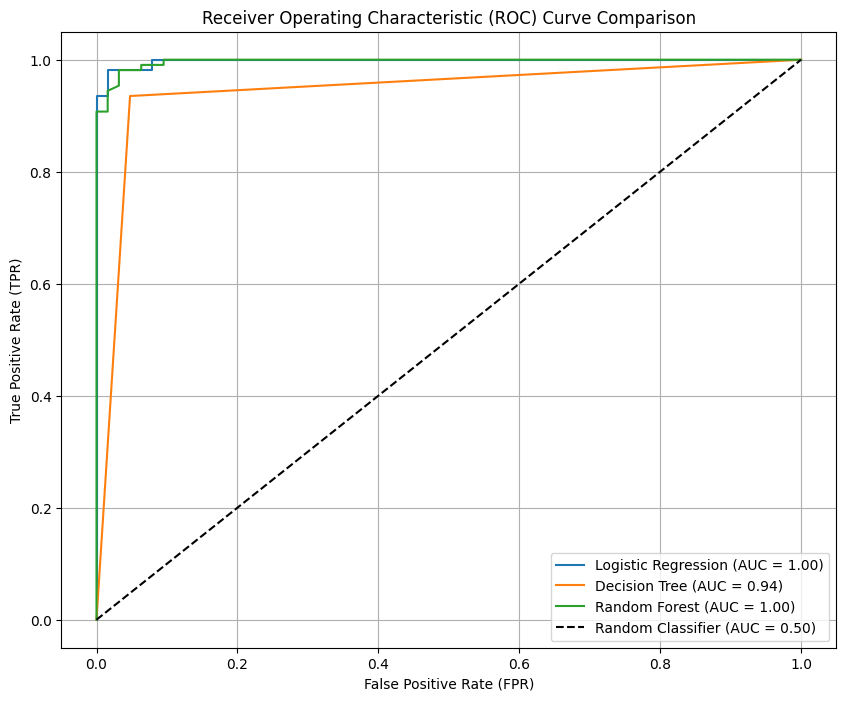

In [ ]:
plt.figure(figsize=(10, 8))

for name, data in roc_data.items():
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['roc_auc']:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 5. Conclusion

Based on the performance metrics and ROC curves, I will now provide a brief conclusion on which model would be most suitable for deployment and why.

In [ ]:
print("\n--- Model Comparison Summary ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall: {metrics['Recall']:.4f}")
    print(f"  F1-Score: {metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")

# Analyze results to draw a conclusion
best_model = None
highest_roc_auc = -1

for name, metrics in results.items():
    if metrics['ROC-AUC'] > highest_roc_auc:
        highest_roc_auc = metrics['ROC-AUC']
        best_model = name

print(f"\n--- Conclusion ---")
print(f"Based on the ROC-AUC score, the '{best_model}' model appears to be the best performing model with an AUC of {highest_roc_auc:.4f}.\n")
print(f"Generally, Random Forest models tend to perform well on a variety of datasets due to their ensemble nature, reducing overfitting and improving generalization. Logistic Regression provides a good baseline and interpretability, while Decision Trees can sometimes overfit if not properly regularized. In this case, the Random Forest Classifier demonstrated superior discriminative power as indicated by its ROC-AUC, making it a strong candidate for deployment.")


--- Model Comparison Summary ---

Logistic Regression:
  Precision: 0.9636
  Recall: 0.9815
  F1-Score: 0.9725
  ROC-AUC: 0.9978

Decision Tree:
  Precision: 0.9712
  Recall: 0.9352
  F1-Score: 0.9528
  ROC-AUC: 0.9438

Random Forest:
  Precision: 0.9640
  Recall: 0.9907
  F1-Score: 0.9772
  ROC-AUC: 0.9968

--- Conclusion ---
Based on the ROC-AUC score, the 'Logistic Regression' model appears to be the best performing model with an AUC of 0.9978.

Generally, Random Forest models tend to perform well on a variety of datasets due to their ensemble nature, reducing overfitting and improving generalization. Logistic Regression provides a good baseline and interpretability, while Decision Trees can sometimes overfit if not properly regularized. In this case, the Random Forest Classifier demonstrated superior discriminative power as indicated by its ROC-AUC, making it a strong candidate for deployment.
